In [54]:
!pip install openml pandas scikit-learn torch
# OpenML : téléchargement et accès à des jeux de données de ML publics
# Pandas : manipulation de données tabulaires (DataFrame)
# Scikit-learn : algorithmes de machine learning classiques, prétraitement, métriques
# PyTorch : calcul tensoriel, autodifférentiation et deep learning
# PennyLane : calcul quantique et modèles hybrides quantique + classique
# Matplotlib : visualisation de données et graphiques

In [55]:
datasets = openml.datasets.list_datasets(output_format="dataframe") ## permet de récupérer la liste des dataset pour tabulaire

In [56]:
import openml
import pandas as pd
from sklearn.model_selection import train_test_split

dataset = openml.datasets.get_dataset(31)

print(dataset.name)
print(dataset.format)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute
)

print(X.shape)
print(y.unique())
print(categorical_indicator) ## Savoir si c'est une catégorie
print(attribute_names)

credit-g
ARFF
(1000, 20)
['good', 'bad']
Categories (2, object): ['good' < 'bad']
[True, False, True, True, False, True, True, False, True, True, False, True, False, True, True, False, True, False, True, True]
['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker']


In [57]:
print(f"Shape : {X.shape}")
print(f"Classes : {y.unique()}") ## Voir les différents labels
print(f"\nAperçu :\n")
X.head() ## Visualiser le tableau

Shape : (1000, 20)
Classes : ['good', 'bad']
Categories (2, object): ['good' < 'bad']

Aperçu :



,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951.0,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096.0,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes
3,<0,42,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes
4,<0,24,delayed previously,new car,4870.0,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=100,
    stratify=y
)

## Séparation des catégories selon categorical_indicator d'abord

list_cat = []
list_num = []

for i in range(len(categorical_indicator)):
  if categorical_indicator[i] == True:
    list_cat.append(i)
  else:
    list_num.append(i)

print(list_cat)
print(list_num)

[0, 2, 3, 5, 6, 8, 9, 11, 13, 14, 16, 18, 19]
[1, 4, 7, 10, 12, 15, 17]


Comme PennyLane ne comprend pas les NaN, la séparation en catégories / numérique va permettre de transformer:
- Les catégories manquantes en la plus fréquente.
- Les valeurs manquantes en la valeur médiane.

In [59]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
import pandas as pd

name_num = [attribute_names[i] for i in list_num]
name_cat = [attribute_names[i] for i in list_cat]

num_imputer = SimpleImputer(strategy="median")
X_train_num = num_imputer.fit_transform(X_train[name_num])
X_test_num  = num_imputer.transform(X_test[name_num])

cat_imputer = SimpleImputer(strategy="most_frequent")
X_train_cat = cat_imputer.fit_transform(X_train[name_cat])
X_test_cat  = cat_imputer.transform(X_test[name_cat])

Standardiser les colonnes numériques, StandardScaler permet d'avoir un écart-type à 1 et une moyenne à 0.

In [60]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_test_num  = scaler.transform(X_test_num)

Change les catégories en chiffre pour chaque classe + les labels juste après

In [61]:
ord_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1 ## INUTILE NORMALEMENT CAR TOUT EST DEJA RE-REMPLI, sécuritééé
)
X_train_cat = ord_encoder.fit_transform(X_train_cat)
X_test_cat  = ord_encoder.transform(X_test_cat)

## +

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

X_train_final = np.hstack([X_train_num, X_train_cat]).astype(np.float32)
X_test_final  = np.hstack([X_test_num,  X_test_cat]).astype(np.float32)

y_train_final = y_train_enc.astype(np.int64)
y_test_final  = y_test_enc.astype(np.int64)

On va faire passer les tableaux numpy en tenseurs PyTorch

In [62]:
import torch
from torch.utils.data import Dataset, DataLoader

class TabularDataset(Dataset):
    def __init__(self, X, y):
        # Convertir numpy → tenseurs PyTorch
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        # PyTorch appelle ça pour connaître la taille du dataset
        return len(self.X)

    def __getitem__(self, idx):
        # PyTorch appelle ça pour récupérer une ligne par index
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train_final, y_train_final)
test_dataset  = TabularDataset(X_test_final,  y_test_final)

DataSet sait comment accéder à chaque ligne par son index (c'est le chef d'orchestre si l'on veut) et DataLoader, lui, vient récupérer petit à petit les batches et venir faire les calculs. On va venir faire deux dataset, un pour le train et un pour le test.

In [63]:
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False
)

In [64]:
import torch
import torch.nn as nn
# torch.nn contiznt tout ce qu'il faut pour construire des réseaux :
# couches, activations, loss functions. C'est le module central de PyTorch.

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_classes, dropout=0.3):
        # input dim: dimension des données d'entrées
        # hidden_dim: nombre de neurones dans la couche principale (d'où la division par deux dans la couche 2)
        # n_classes: nombre de classe
        # dropout: taux d'oubli des neuronnes pour ne pas rester sur des "bases"

        super().__init__() ## Obligatoire, sinon PyTorch ne peut pas suivre les paramètres


        # Exemple de couche de neuronnes simple
        self.net = nn.Sequential(
            # Couche 1
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Couche 2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Couche de sortie — pas d'activation ici
            nn.Linear(hidden_dim // 2, n_classes),
        )

    def forward(self, x):
        return self.net(x)

In [65]:
# Instanciation du modèle
input_dim  = X_train_final.shape[1]
n_classes  = len(le.classes_)
hidden_dim = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = MLP(input_dim=input_dim, hidden_dim=hidden_dim, n_classes=n_classes).to(device)
print(model)
print(f"\nDevice utilisé : {device}")


MLP(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=2, bias=True)
  )
)

Device utilisé : cpu


In [66]:
import torch.optim as optim

# CrossEntropyLoss = softmax + log + NLLLoss en une seule opération
# Parfaite pour la classification multiclasse (3 classes ici)
criterion = nn.CrossEntropyLoss()

# Adam : l'optimiseur par défaut pour débuter
# lr=1e-3 est un bon point de départ
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Scheduler : réduit le lr si la loss stagne (patience=5 epochs)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

## Boucle d'entraînement

On itère sur les epochs. À chaque epoch :
- **Phase train** : forward → loss → backward → step
- **Phase eval** : on désactive le gradient (`torch.no_grad`) pour mesurer la précision sans modifier les poids

In [67]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # active BatchNorm et Dropout
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()          # réinitialise les gradients
        logits = model(X_batch)        # forward pass
        loss   = criterion(logits, y_batch)
        loss.backward()                # backpropagation
        optimizer.step()               # mise à jour des poids

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()  # désactive BatchNorm / Dropout
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():  # pas de calcul de gradient
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)

    return total_loss / total, correct / total


On lance maintenant la boucle sur `N_EPOCHS` epochs en appelant les deux fonctions ci-dessus.

In [68]:
N_EPOCHS = 50

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc = evaluate(model, test_loader, criterion, device)

    scheduler.step(va_loss)

    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(va_loss);   val_accs.append(va_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS} | "
              f"Train loss {tr_loss:.4f}  acc {tr_acc:.3f} | "
              f"Val loss {va_loss:.4f}  acc {va_acc:.3f}")


Epoch   1/50 | Train loss 0.6528  acc 0.659 | Val loss 0.6018  acc 0.720
Epoch  10/50 | Train loss 0.5121  acc 0.732 | Val loss 0.4591  acc 0.800
Epoch  20/50 | Train loss 0.4791  acc 0.758 | Val loss 0.4602  acc 0.800
Epoch  30/50 | Train loss 0.4609  acc 0.761 | Val loss 0.4570  acc 0.810
Epoch  40/50 | Train loss 0.4555  acc 0.786 | Val loss 0.4573  acc 0.820
Epoch  50/50 | Train loss 0.4700  acc 0.753 | Val loss 0.4557  acc 0.820


## Visualisation des courbes d'apprentissage

On trace la **loss** et l'**accuracy** sur train et validation pour détecter un éventuel surapprentissage.

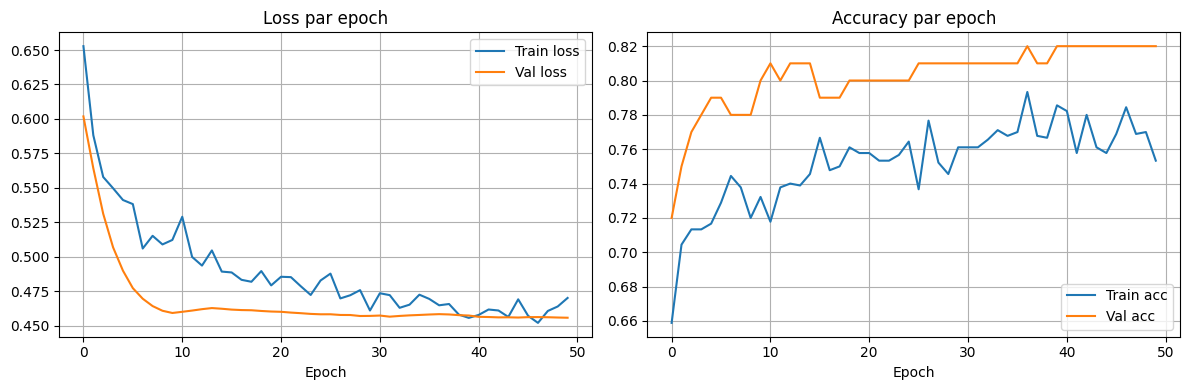

In [69]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train loss')
axes[0].plot(val_losses,   label='Val loss')
axes[0].set_title('Loss par epoch'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(train_accs, label='Train acc')
axes[1].plot(val_accs,   label='Val acc')
axes[1].set_title('Accuracy par epoch'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


## Évaluation finale

Rapport de classification complet (précision, rappel, F1) sur le jeu de test.

In [70]:
from sklearn.metrics import classification_report

model.eval()
all_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        logits = model(X_batch.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())

print(classification_report(
    y_test_final,
    all_preds,
    target_names=le.classes_
))


              precision    recall  f1-score   support

         bad       0.75      0.60      0.67        30
        good       0.84      0.91      0.88        70

    accuracy                           0.82       100
   macro avg       0.80      0.76      0.77       100
weighted avg       0.81      0.82      0.81       100

